In [48]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()
# from cmdstanpy import CmdStanModel

In [49]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
from cmdstanpy import from_csv
import arviz as az
from pathlib import Path

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid
from add_noise import Add_noise

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

# 1 . Data Generation with disease induced Deaths

# 1 . META POPULATION MODEL - NO TRAVEL
$$
\begin{aligned}
S'_{p} &= -\sum_{j=1}^n \beta_{j}\frac{S_{p}I_{j}}{N_j} \\
E'_{p} &= \sum_{j=1}^n \beta_{j}\frac{S_{p}I_{j}}{N_j} - \sigma_{p} E_{p}\\
I'_{p} &= \sigma_{p} E_{p} - \gamma_{p} I_{p} \\
R'_{p} &= \gamma_{p} I_{p}
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Removed individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_{j} $: Transmission rate in patch $ p $ with individual contact from patch $j$.
- $ \sigma_{p} $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_{p} $: Recovery rate (inverse of the infectious period).
<!-- - $ \alpha_{p}$: Disease induced death rate. -->

In [50]:
# Define the SEIR model differential equations
def seir_model(state, t, N, beta, sigma, gamma):
    n_patches = len(N)
    S = state[:n_patches]
    E = state[n_patches:2*n_patches]
    I = state[2*n_patches:3*n_patches]
    R = state[3*n_patches:4*n_patches]
    C = state[4*n_patches:]  # Cumulative cases

    dSdt = np.zeros(n_patches)
    dEdt = np.zeros(n_patches)
    dIdt = np.zeros(n_patches)
    dRdt = np.zeros(n_patches)
    dCdt = np.zeros(n_patches)

    for p in range(n_patches):
        # Force of infection for patch p from all patches j
        foi = sum(beta[p, j] * S[p] * I[j] / N[j] for j in range(n_patches))
        dSdt[p] = -foi
        dEdt[p] = foi - sigma[p] * E[p]
        dIdt[p] = sigma[p] * E[p] - gamma[p] * I[p]
        dRdt[p] = gamma[p] * I[p]
        dCdt[p] = sigma[p] * E[p]

    return np.concatenate([dSdt, dEdt, dIdt, dRdt, dCdt])

In [51]:
n_patches = 3 
T = 96  #371/7 #96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone

## Get the Parameters
beta = np.array([[0.3, 0.03, 0.02], 
           [0.03, 0.4, 0.05], 
           [0.02, 0.05, 0.35]])*7
# beta = np.array([0.3, 0.4, 0.35])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/6.7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported


# Initial conditions
E0 = np.array([10, 1, 1])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
C0 = np.array([10,10,10])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


In [52]:
np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

array([11499980.,  4499989.,  6799989.])

In [53]:

# Solve the ODE system
solution = odeint(seir_model, y0, t, args=(N, beta, sigma, gamma))

# Extract variables
S = solution[:, :n_patches]
E = solution[:, n_patches:2*n_patches]
I = solution[:, 2*n_patches:3*n_patches]
R = solution[:, 3*n_patches:4*n_patches]
C = solution[:, 4*n_patches:]

## Total per patch (sum over resident patches i)
S_total = S #np.sum(S, axis=1)
E_total = E #np.sum(E, axis=1)
I_total = I #np.sum(I, axis=1)
R_total = R #np.sum(R, axis=1)
C_total = C #np.sum(C, axis=1)

In [54]:
C_total

array([[1.00000000e+01, 1.00000000e+01, 1.00000000e+01],
       [2.55340813e+01, 1.94669545e+01, 1.90737036e+01],
       [5.78284259e+01, 4.35199757e+01, 4.12621373e+01],
       [1.20516567e+02, 9.14850453e+01, 8.40994268e+01],
       [2.42124086e+02, 1.86136384e+02, 1.66557045e+02],
       [4.78332704e+02, 3.72531611e+02, 3.25887781e+02],
       [9.37666880e+02, 7.39087812e+02, 6.34728022e+02],
       [1.83173782e+03, 1.45911466e+03, 1.23478236e+03],
       [3.57326351e+03, 2.87197240e+03, 2.40260340e+03],
       [6.96704562e+03, 5.64113775e+03, 4.67780626e+03],
       [1.35810259e+04, 1.10602817e+04, 9.11212536e+03],
       [2.64630840e+04, 2.16393019e+04, 1.77498689e+04],
       [5.15097069e+04, 4.22014115e+04, 3.45419788e+04],
       [1.00018772e+05, 8.18446230e+04, 6.70370105e+04],
       [1.93227407e+05, 1.57117052e+05, 1.29333545e+05],
       [3.69585172e+05, 2.96028078e+05, 2.46617464e+05],
       [6.93767850e+05, 5.39553649e+05, 4.60111689e+05],
       [1.25977821e+06, 9.30966

## Get the New Infections

In [55]:
## get the new infected individuals at each time
Infections = np.zeros([T, n_patches])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Add random Noise to the data

In [56]:
observed_cases = Add_noise(Infections, reporting_rate = reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])

In [57]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone']
}

raw_coupling = pd.DataFrame(data)
raw_coupling.to_csv('Data/coupling_synthetic_ebola_dataset_with_death.csv', index=False)
raw_coupling.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,10.000000,0.000000,0,4.499989e+06,...,10.000000,0.000000,0,6.799989e+06,1.000000,10.000000,0.000000,10.000000,0.000000,0
1,2013-12-29,1,1.149995e+07,27.192457,15.938531,9.595551,25.534081,15.534081,19,4.499961e+06,...,19.466954,9.466954,6,6.799962e+06,18.479565,9.172530,9.901173,19.073704,9.073704,17
2,2013-12-30,2,1.149989e+07,53.128610,30.597367,27.231059,57.828426,32.294345,28,4.499916e+06,...,43.519976,24.053021,30,6.799922e+06,36.487698,16.698502,24.563635,41.262137,22.188434,21
3,2013-12-31,3,1.149978e+07,103.000226,59.223122,61.293446,120.516567,62.688141,66,4.499829e+06,...,91.485045,47.965070,83,6.799846e+06,70.111839,31.881681,52.217745,84.099427,42.837289,26
4,2014-01-01,4,1.149956e+07,199.924000,114.832411,127.291675,242.124086,121.607519,148,4.499657e+06,...,186.136384,94.651338,40,6.799698e+06,135.194178,61.306314,105.250731,166.557045,82.457619,68


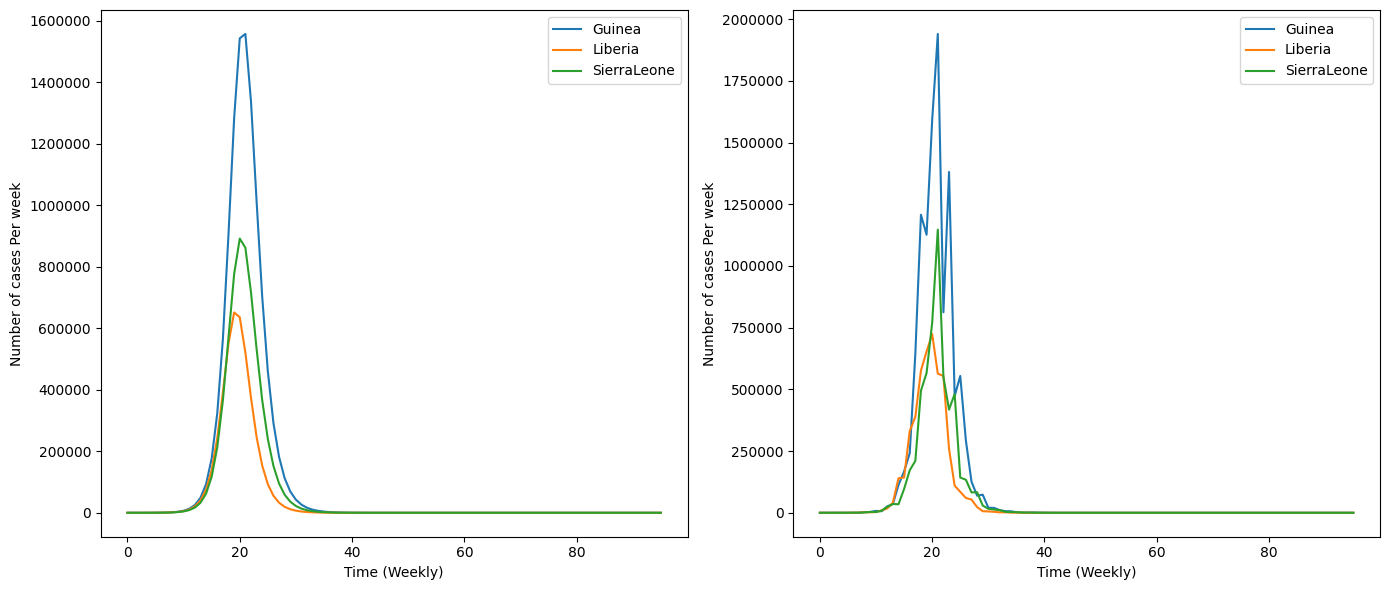

In [58]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw_coupling[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')
    ax[0].ticklabel_format(style='plain', axis='y')

    ax[1].plot(raw_coupling[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')
    ax[1].ticklabel_format(style='plain', axis='y')

    # ax[2].plot(raw_coupling[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_with_coupling.pdf')
plt.show()

In [59]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

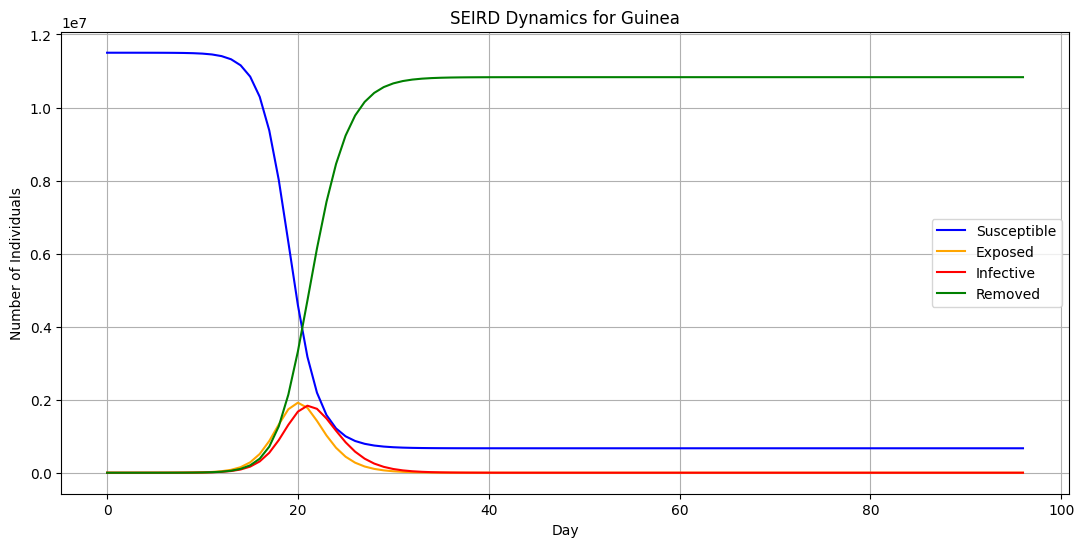

In [60]:
plot_SEIR(raw_coupling, 'Guinea')

## Fit the Model

In [61]:
weekly_coupling = raw_coupling[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly_coupling.tail()
ts = weekly_coupling.values.T

In [ ]:
# %run fit_metapopulation.py

In [25]:

# Load Guinea fit
fit_coupling_model = from_csv('outputs/metapopulation_20250608_195509/metapopulation-*_*.csv')

print("All fit loaded")
print(fit_coupling_model.diagnose())

All fit loaded
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
3 of 1000 (0.30%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



In [21]:
# fit_coupling_model = coupling_model.sample(data = seir_data,
#                                            iter_sampling = 1000,
#                                         #    parallel_chains=True,
#                                            chains = 4,
#                                            seed = 0)

In [26]:
coupling_summary = fit_coupling_model.summary()
coupling_summary.filter(items=("beta[1]","beta[2]", "beta[3]", 
                               "sigma[1]","sigma[2]","sigma[3]", 
                               "gamma[1]", "gamma[2]","gamma[3]",
                               "recovery_time[1]", "recovery_time[2]", "recovery_time[3]", 
                               "incubation_period[1]", "incubation_period[2]", "incubation_period[3]", 
                               "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma[1],0.970326,0.003003,0.135781,0.122045,0.789265,0.951626,1.212970,2290.56,2026.49,1.00025
sigma[2],0.808330,0.001267,0.065244,0.060414,0.712726,0.800581,0.925270,2938.60,2233.56,1.00135
sigma[3],1.194440,0.003891,0.188447,0.164873,0.942271,1.166430,1.524170,2734.36,2281.68,1.00038
gamma[1],1.878220,0.012641,0.647237,0.512394,1.149260,1.727140,3.115540,3101.76,2782.62,1.00109
gamma[2],0.756876,0.001124,0.056727,0.055013,0.672978,0.750930,0.856400,2661.99,2360.98,1.00073
gamma[3],2.573410,0.019928,1.024380,0.838937,1.409840,2.321630,4.459610,2925.66,2326.10,1.00145
incubation_period[1],1.049080,0.002859,0.135330,0.137615,0.824419,1.050830,1.267000,2290.56,2026.49,1.00015
incubation_period[2],1.244920,0.001820,0.097362,0.095902,1.080770,1.249100,1.403060,2938.54,2233.56,1.00123
incubation_period[3],0.856131,0.002385,0.123524,0.122815,0.656095,0.857311,1.061260,2734.35,2281.68,1.00079
phi,4.912340,0.010829,0.690261,0.681499,3.846560,4.871140,6.101560,4080.18,2964.66,1.00081


In [27]:
coupling_summary.filter(items=("beta_mat[1,1]","beta_mat[1,2]", "beta_mat[1,3]", 
                               "beta_mat[2,1]","beta_mat[2,2]", "beta_mat[2,3]", 
                               "beta_mat[3,1]","beta_mat[3,2]", "beta_mat[3,3]", ), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
"beta_mat[1,1]",1.471830,0.010246,0.522684,0.520808,0.723056,1.422190,2.392170,2578.28,2550.71,1.001860
"beta_mat[1,2]",0.536142,0.003303,0.148633,0.148740,0.296550,0.532056,0.788209,2016.09,2478.69,1.000100
"beta_mat[1,3]",0.165418,0.001404,0.089372,0.069949,0.062882,0.145127,0.337065,4807.29,3078.23,0.999955
"beta_mat[2,1]",0.159289,0.001175,0.074040,0.062560,0.069205,0.145251,0.293405,4702.56,2947.89,1.000360
"beta_mat[2,2]",2.496190,0.002776,0.132119,0.130128,2.287680,2.493500,2.723040,2282.18,2472.45,1.001430
"beta_mat[2,3]",0.286891,0.002510,0.135597,0.112139,0.125847,0.260866,0.538016,3835.15,2847.51,1.000990
"beta_mat[3,1]",0.135038,0.001081,0.067302,0.056234,0.055394,0.121508,0.264364,4183.71,2786.44,0.999992
"beta_mat[3,2]",0.515162,0.002154,0.108876,0.107285,0.349279,0.510360,0.702113,2538.06,2365.71,1.000490
"beta_mat[3,3]",1.345320,0.009590,0.515972,0.484432,0.653253,1.260320,2.296560,3022.31,2595.20,1.001740


In [ ]:
# # Extract posterior samples
# posterior = fit_coupling_model.draws_pd()

# ## save the posterior samples
# posterior.to_csv('./Data/posterior_samples_coupling.csv', index=False)

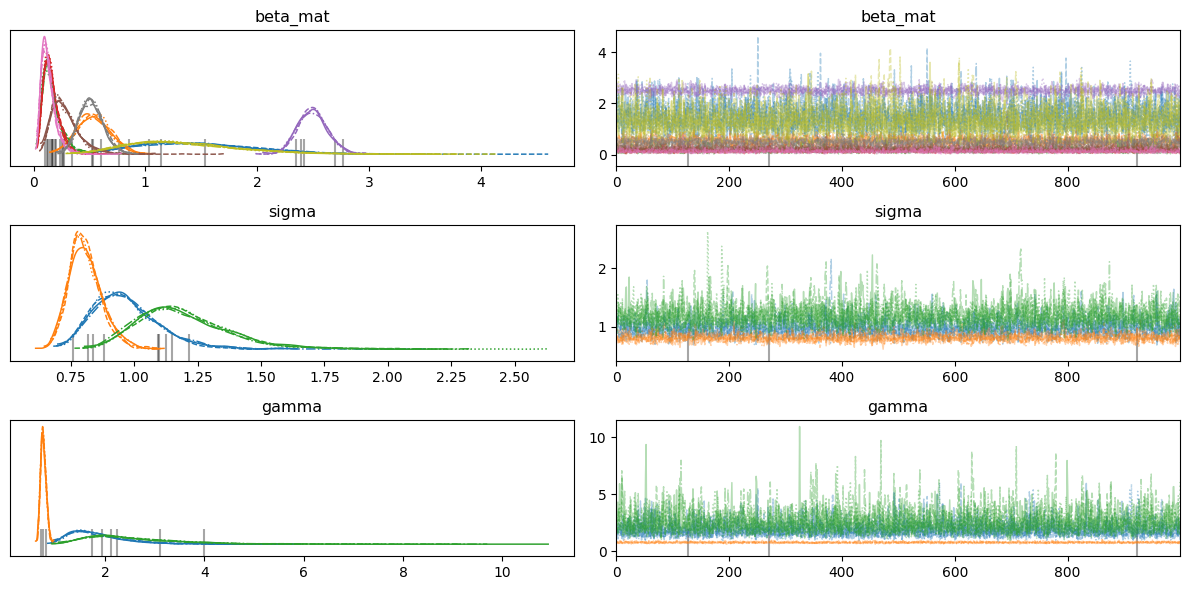

In [28]:

az.plot_trace(fit_coupling_model, var_names=["beta_mat", "sigma", "gamma"])
plt.tight_layout()
plt.show()

In [18]:
idata = az.from_cmdstanpy(fit_coupling_model)  # or az.from_cmdstan(fit)
# shape: (draws, N_patches, n_weeks)
pred_inc = idata.posterior['pred_incidence'].values  # shape: (chains, draws, N_patches, n_weeks)
if pred_inc.ndim == 4:  # combine chains
    pred_inc = pred_inc.reshape(-1, *pred_inc.shape[2:])

In [19]:
np.array([0.3, 0.4, 0.35])*7

array([2.1 , 2.8 , 2.45])

In [34]:
pred_inc.shape

(4000, 3, 53)

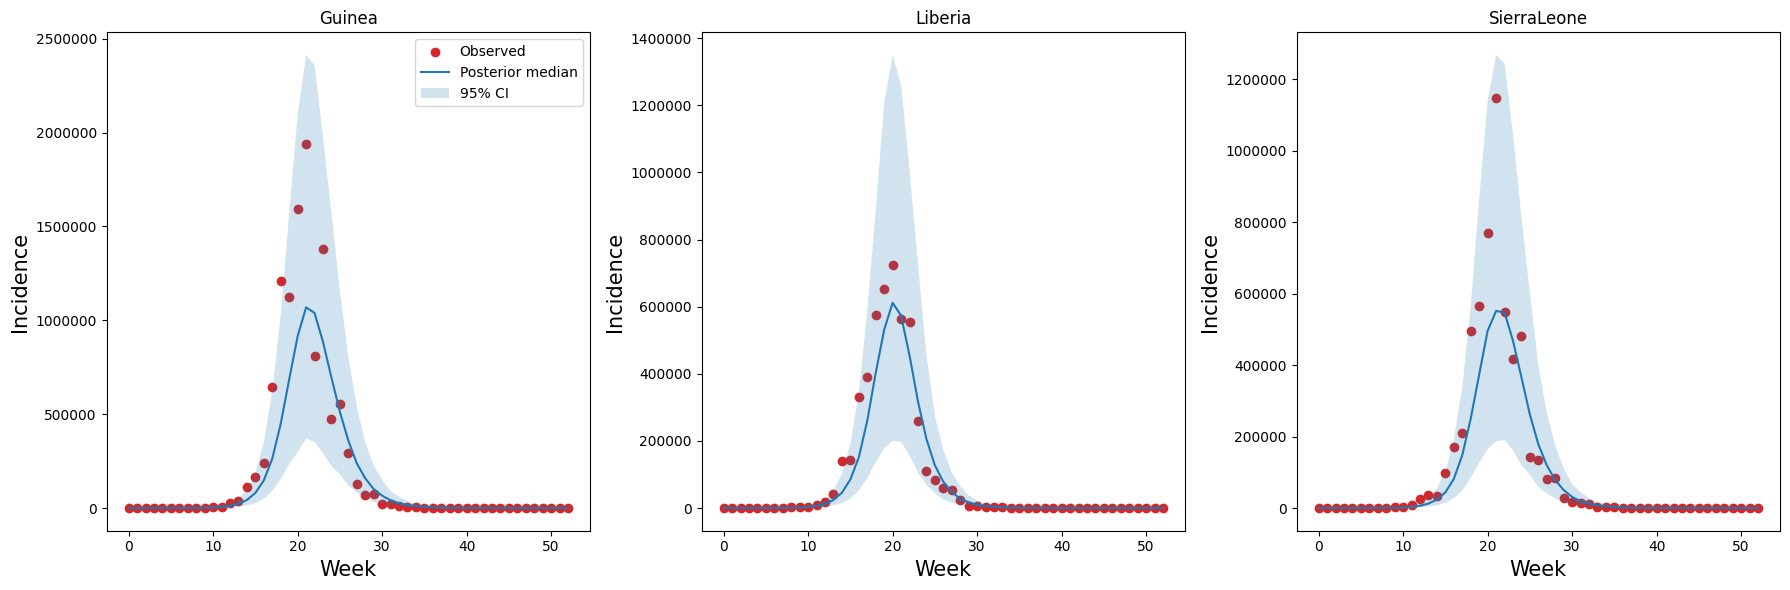

In [63]:
patch_names = ["Guinea", "Liberia", "SierraLeone"]
weeks = np.arange(pred_inc.shape[2])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)
for i, country in enumerate(patch_names):
    ax = axes[i]
    y_median = np.median(pred_inc[:, i, :], axis=0)
    y_lower = np.percentile(pred_inc[:, i, :], 2.5, axis=0)
    y_upper = np.percentile(pred_inc[:, i, :], 97.5, axis=0)
    # Replace with your observed data for each country
    ax.scatter(weeks, ts[i][:53], color='tab:red', label="Observed" if i==0 else None)
    ax.plot(weeks, y_median, color='tab:blue', label="Posterior median" if i==0 else None)
    ax.fill_between(weeks, y_lower, y_upper, alpha=0.2, label="95% CI" if i==0 else None)
    ax.set_title(country)
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_xlabel("Week", fontsize=15)
    ax.set_ylabel("Incidence", fontsize=15)
    if i == 0:
        ax.legend()
plt.tight_layout()
plt.savefig(f'images/poseterior_check_meta.pdf')
plt.show()

# Calculating R0

R0 median: 3.3650581565060715
95% CI: [2.95996272 3.80124937]


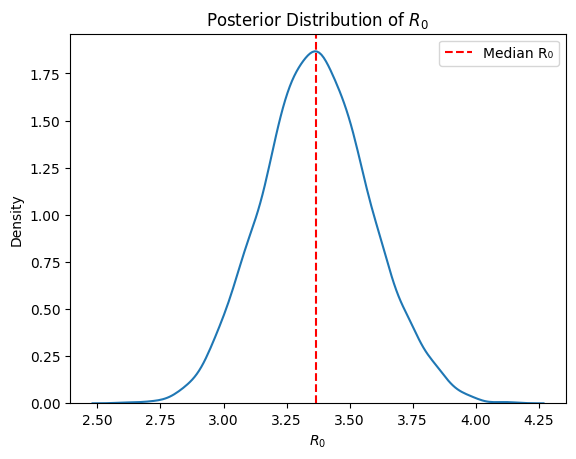

In [64]:
posterior = fit_coupling_model.draws_pd()
ngm_draws = posterior[[f'NGM[{i},{j}]' for i in range(1, 4) for j in range(1, 4)]].values
ngm_draws = ngm_draws.reshape(-1, 3, 3)  # shape: (n_draws, 3, 3)

import numpy as np
from numpy.linalg import eigvals

R0_draws = np.array([max(eigvals(K).real) for K in ngm_draws])

print("R0 median:", np.median(R0_draws))
print("95% CI:", np.percentile(R0_draws, [2.5, 97.5]))

sns.kdeplot(R0_draws)
plt.axvline(np.median(R0_draws), color='red', linestyle='--', label='Median R₀')
plt.title('Posterior Distribution of $R_0$')
plt.xlabel('$R_0$')
plt.ylabel('Density')
plt.legend()
plt.show()


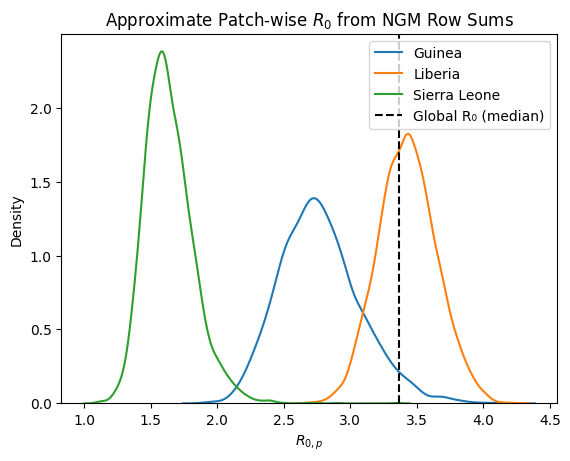

In [65]:
R0_patch_draws = ngm_draws.sum(axis=2)  # shape: (n_draws, n_patches)

# Now plot for each country:
for i, country in enumerate(["Guinea", "Liberia", "Sierra Leone"]):
    sns.kdeplot(R0_patch_draws[:, i], label=country)

plt.axvline(np.median(R0_draws), color='black', linestyle='--', label='Global R₀ (median)')
plt.title("Approximate Patch-wise $R_0$ from NGM Row Sums")
plt.xlabel("$R_{0,p}$")
plt.ylabel("Density")
plt.legend()
plt.show()


# Posterior Checks

In [66]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_coupling_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([[0.3, 0.03, 0.02], 
           [0.03, 0.4, 0.05], 
           [0.02, 0.05, 0.35]])*7
# beta = np.array([0.3, 0.4, 0.35])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/6.7, 1/6])*7 # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
# r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

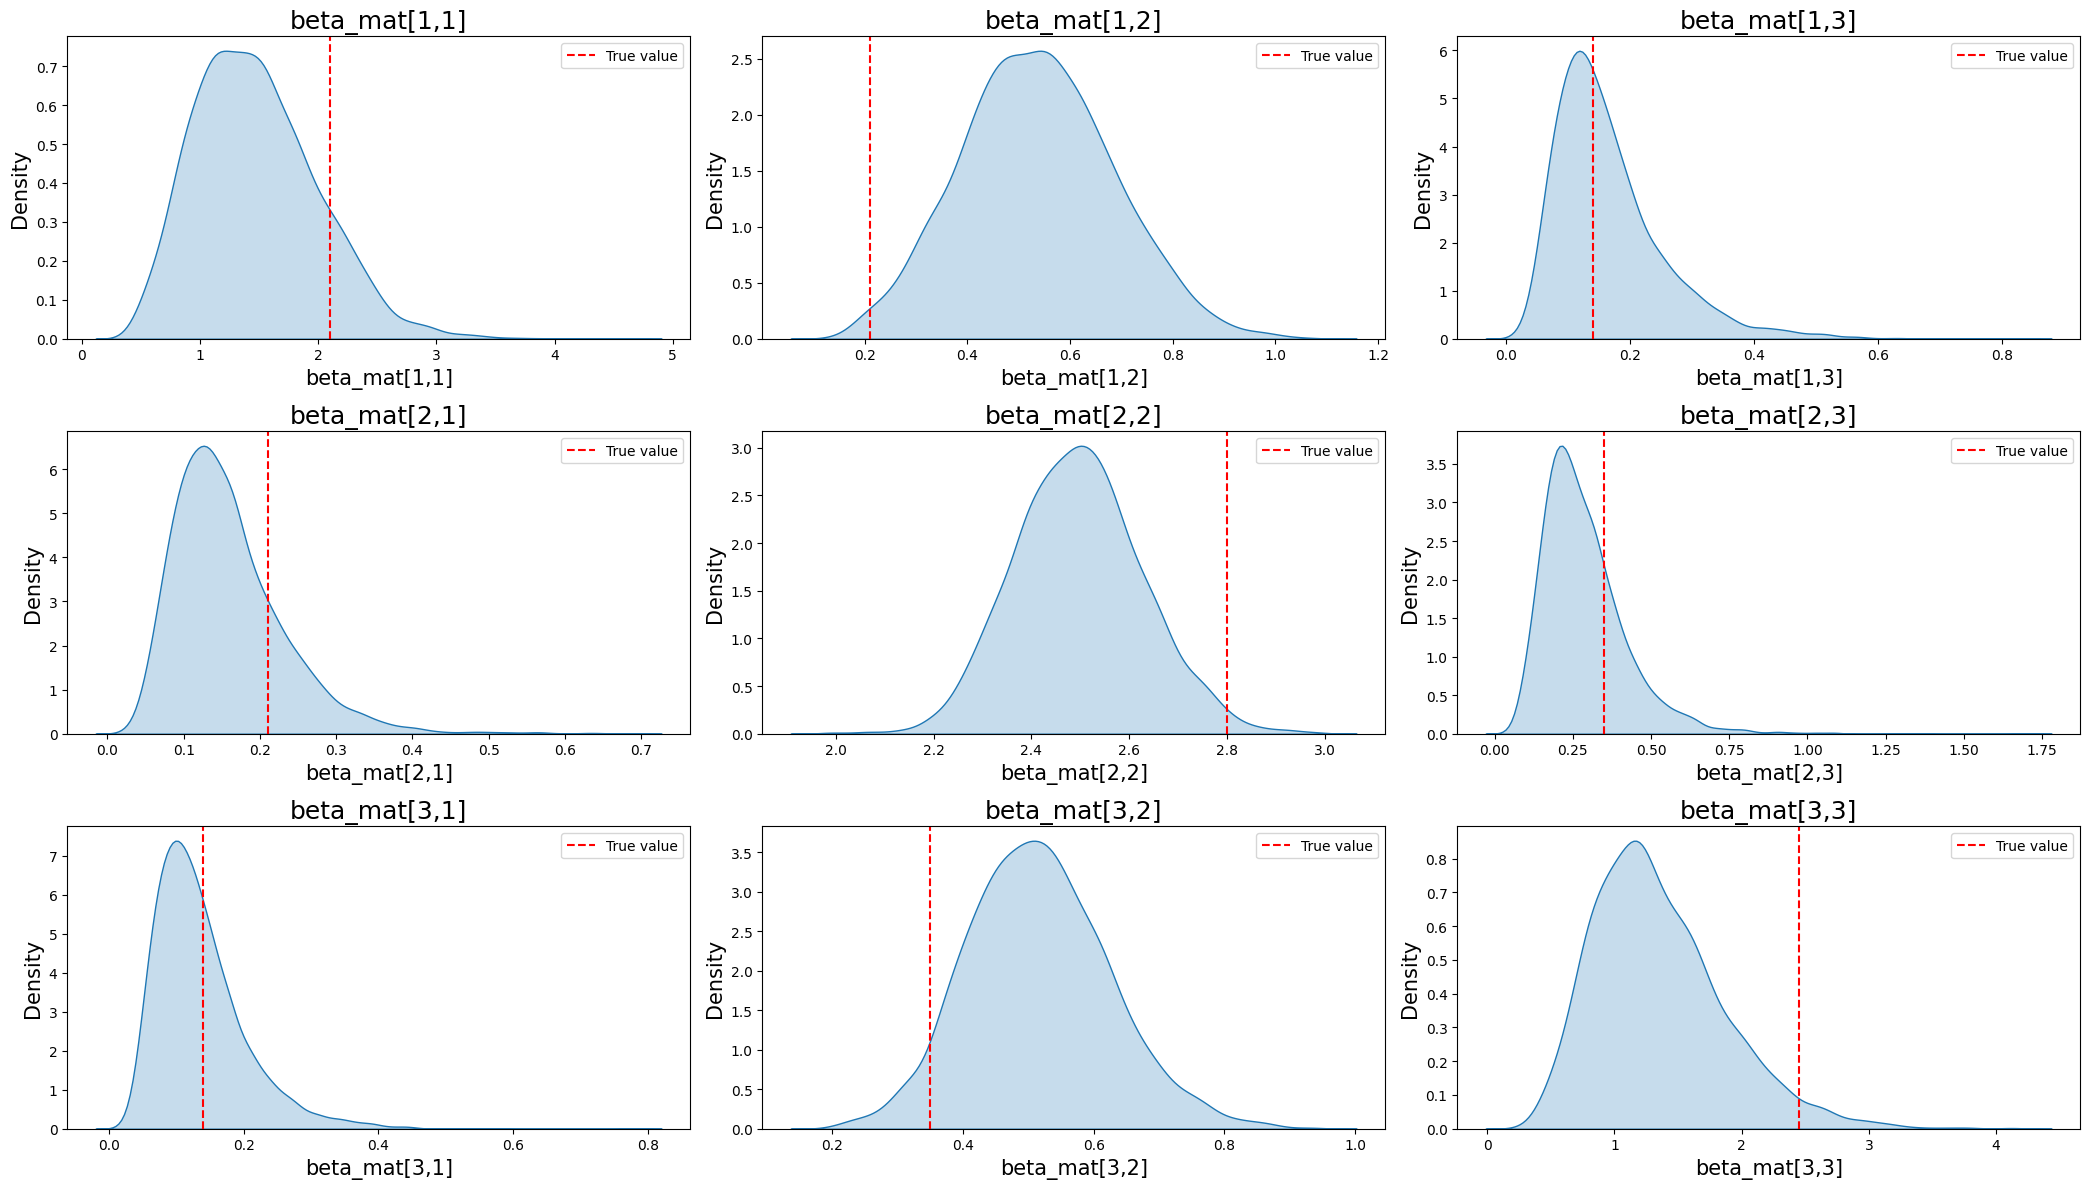

In [67]:
parameters = ['beta_mat[1,1]', 'beta_mat[1,2]', 'beta_mat[1,3]', 
              'beta_mat[2,1]', 'beta_mat[2,2]', 'beta_mat[2,3]',
              'beta_mat[3,1]','beta_mat[3,2]','beta_mat[3,3]']
                
t = {'beta_mat[1,1]':beta[0,0], 'beta_mat[1,2]':beta[0, 1], 'beta_mat[1,3]':beta[0, 2], 
     'beta_mat[2,1]':beta[1, 0], 'beta_mat[2,2]':beta[1, 1], 'beta_mat[2,3]':beta[1, 2],
     'beta_mat[3,1]':beta[2,0],'beta_mat[3,2]':beta[2,1],'beta_mat[3,3]':beta[2, 2], }

plot_posterior_kde_grid(fit_coupling_model, parameters=parameters, n_cols=3, true_values=t)

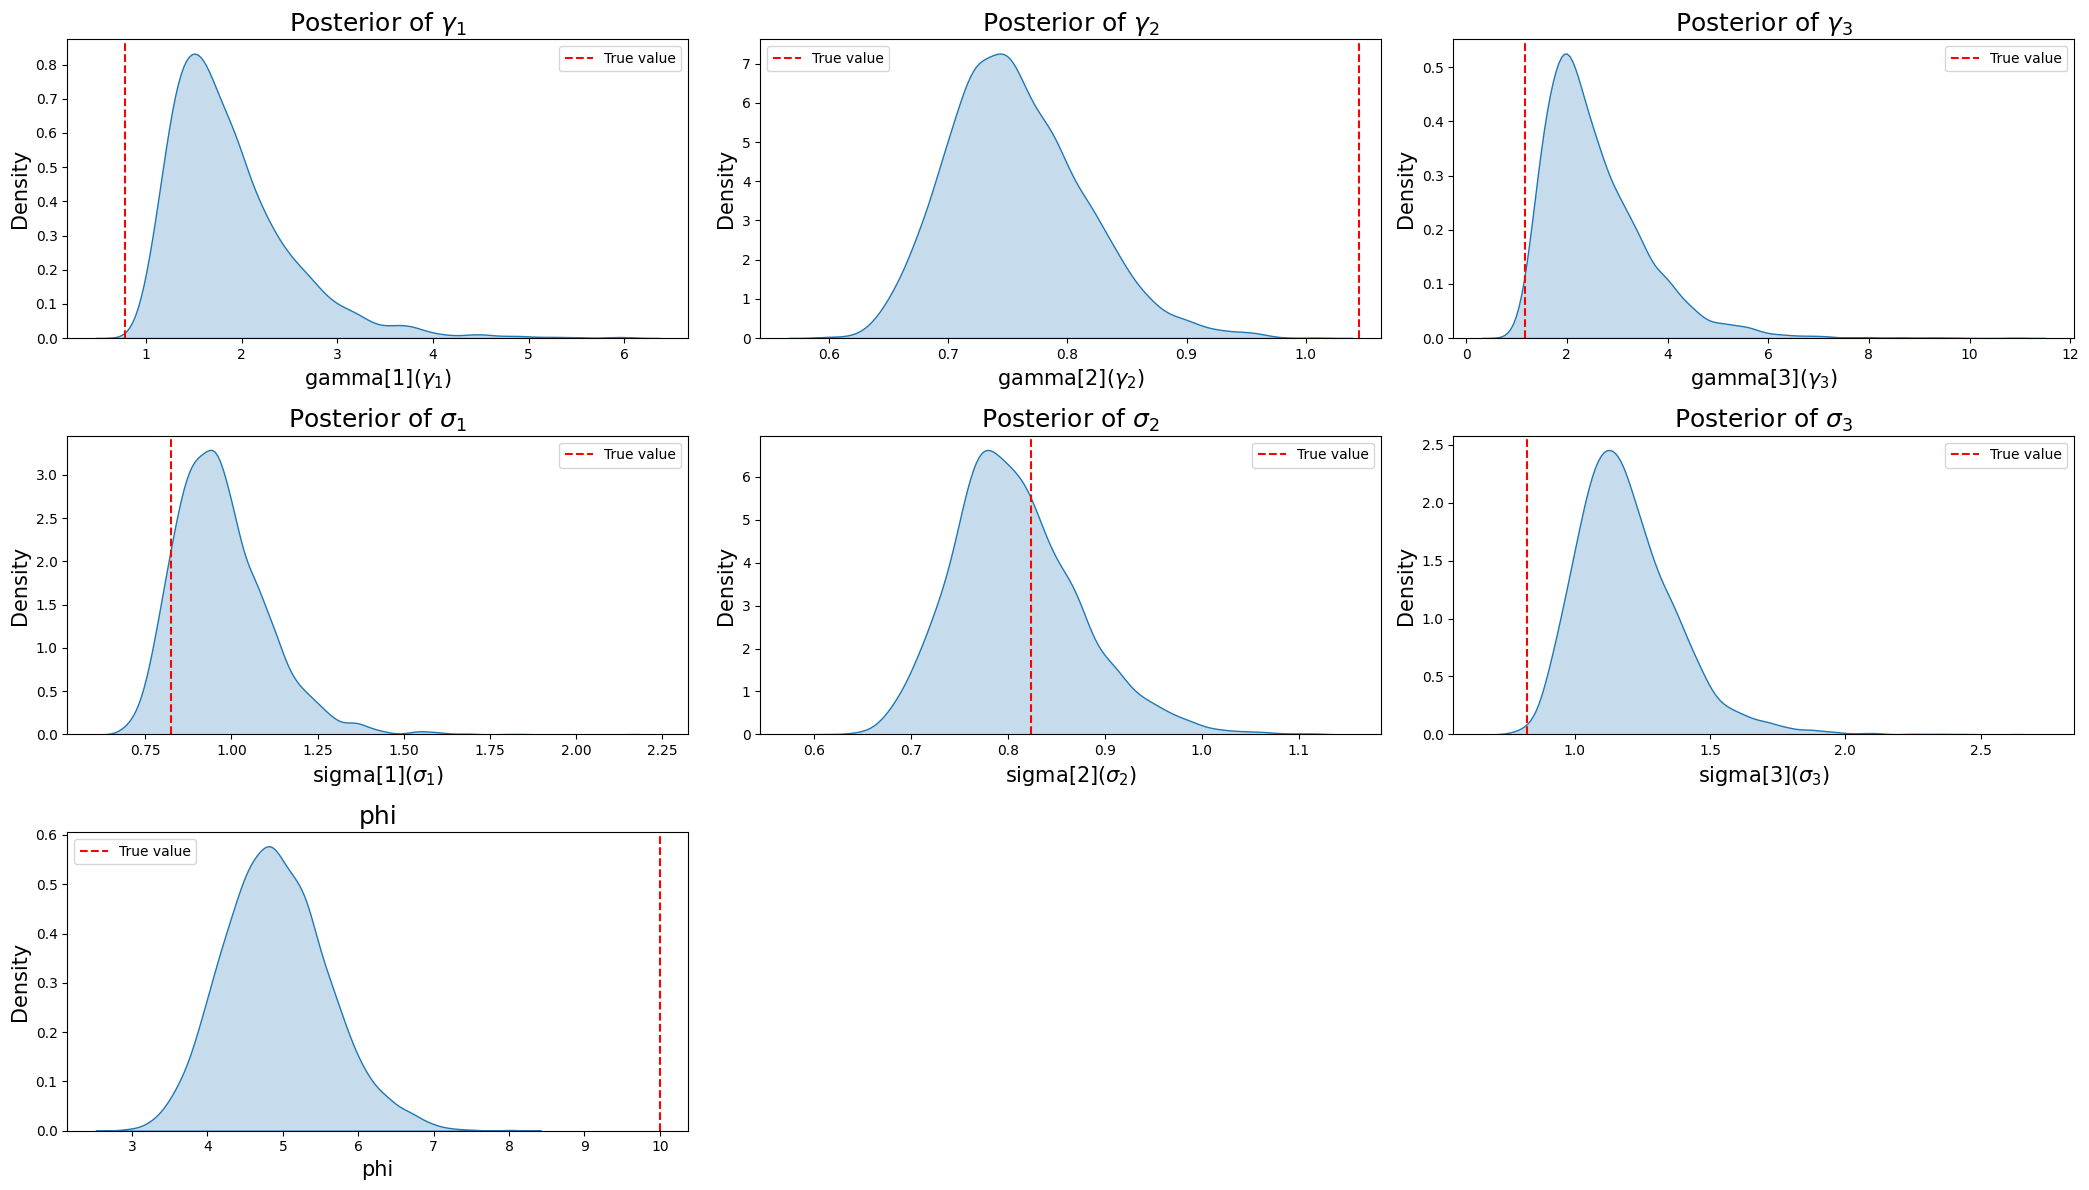

In [68]:
parameters = ["gamma[1]","gamma[2]", "gamma[3]", 
                "sigma[1]","sigma[2]",'sigma[3]', 'phi']
                
t = {'gamma[1]': gamma[0], 'gamma[2]': gamma[1], 'gamma[3]': gamma[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1], 'sigma[3]': sigma[2],
    'phi': phi, }

plot_posterior_kde_grid(fit_coupling_model, parameters=parameters, n_cols=3, true_values=t)

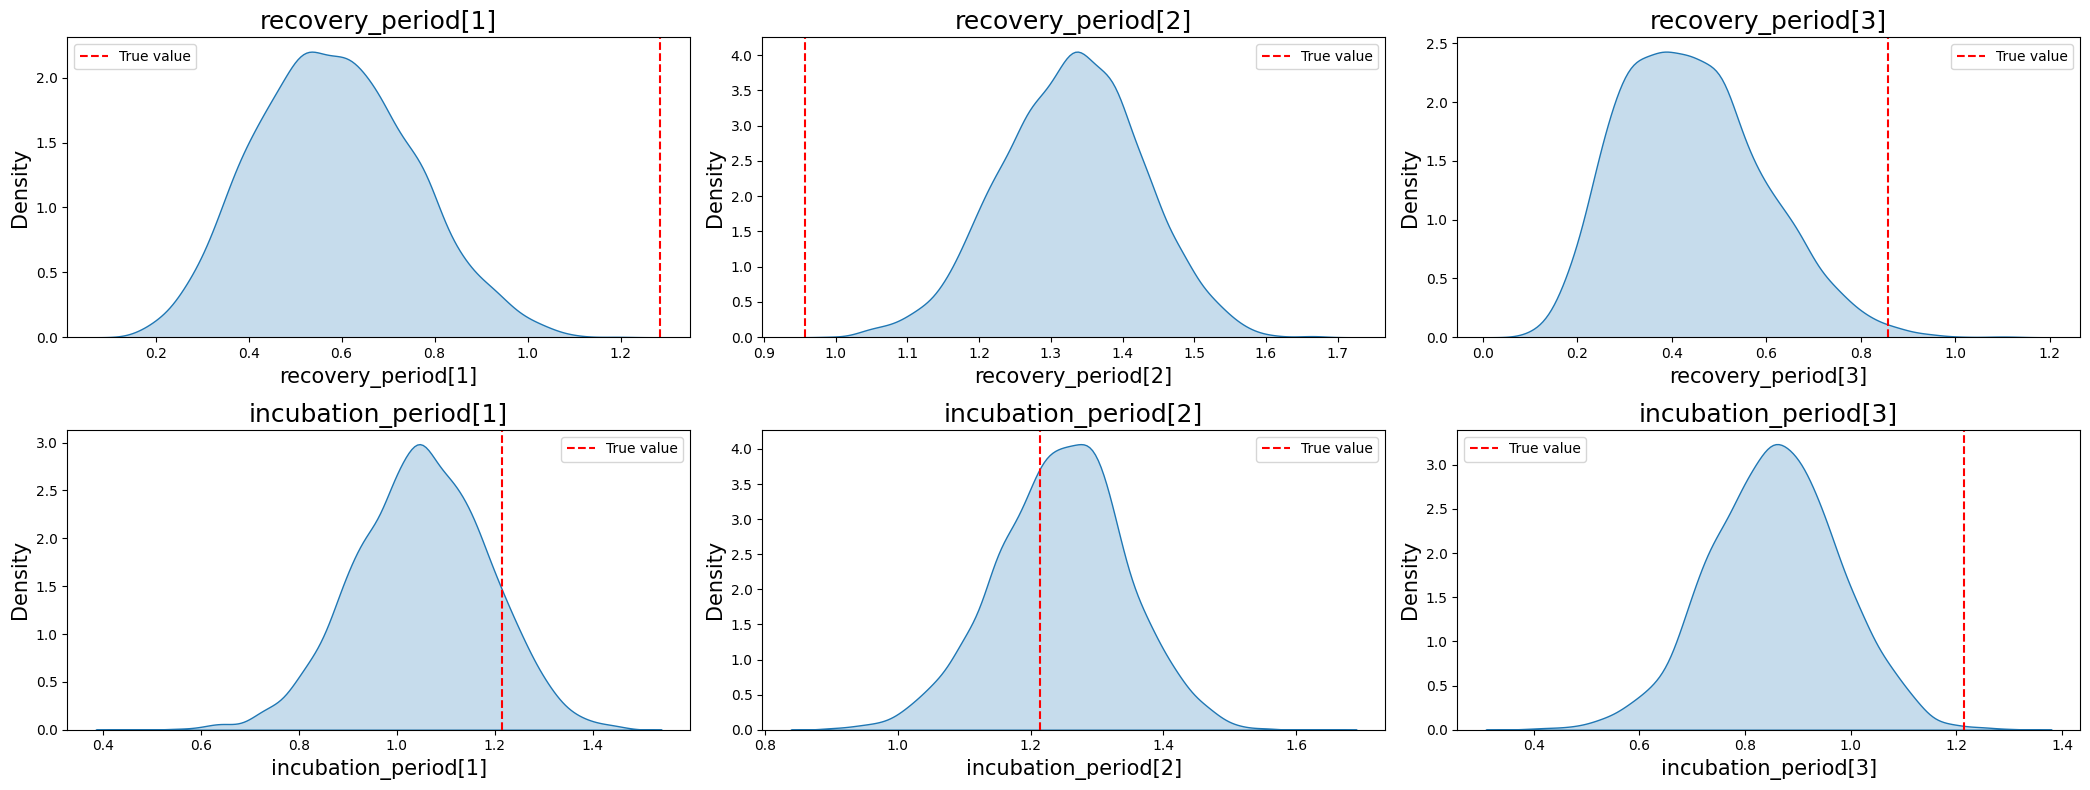

In [69]:
parameters = ["recovery_period[1]","recovery_period[2]", "recovery_period[3]", 
                "incubation_period[1]","incubation_period[2]",'incubation_period[3]']
                
t = {'recovery_period[1]': rec[0], 'recovery_period[2]': rec[1], 'recovery_period[3]': rec[2],
    'incubation_period[1]': incu[0], 'incubation_period[2]': incu[1], 'incubation_period[3]': incu[2],
    'phi': phi, }

plot_posterior_kde_grid(fit_coupling_model, parameters=parameters, n_cols=3, true_values=t)

## 2 . Create the SEIRD Patch model

### simple model with Death compartment

---
### Residents of patch i currently in patch i

---

$$
\begin{aligned}
{S'}_{ii} &= -\sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} + \sum_{k=1}^n r_{ij} S_{ii} - g_i S_{ii} \\
{E'}_{ii} &= \sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} - \sigma E_{ii} + \sum_{k=1}^n r_{ij} E_{ii} - g_i E_{ii} \\
{I'}_{ii} &= \sigma E_{ii} - (\gamma + \alpha) I_{ii} + \sum_{k=1}^n r_{ij} I_{ii} - g_i I_{ii} \\
{R'}_{ii} &= \gamma I_{ii} + \sum_{k=1}^n r_{ij} R_{ii} - g_i R_{ii} \\
{D'}_{ii} &= \alpha I_{ii}
\end{aligned}
$$

---
### Residents of patch i currently in patch j

---
$$
\begin{aligned}
S'_{ij} &= -\sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} + g_i m_{ji}S_{ii} - r_{ij}S_{ij}\\
E'_{ij} &= \sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} - \sigma E_{ij} + g_i m_{ji}E_{ii} - r_{ij}E_{ij}\\
I'_{ij} &= \sigma E_{ij} - (\gamma + \alpha)I_{ij} + g_im_{ji}I_{ii} - r_{ij}I_{ij}\\
R'_{ij} &= \gamma I_{ij} + g_im_{ji}R_{ii} - r_{ij}R_{ij}\\
D'_{ij} &= \alpha I_{ij}
\end{aligned}
$$


- $S, E, I, R, D$: Susceptible, Exposed, Infectious, Recovered, and Dead compartments
- $\beta_{ik}$: Transmission rate from patch k to individuals in patch i
- $\sigma$: Rate at which exposed individuals become infectious (1/incubation period)
- $\gamma$: Recovery rate for infectious individuals
- $\alpha$: Disease-induced death rate
- $g_i$: Rate at which individuals leave patch i
- $r_{ij}$: Rate of return from patch j to patch i
- $m_{ji}$: fraction of individuals from patch i to patch j
- $k_j$: contact rate in patch j
- $N_j$: Total population in patch j

---
## Likelihoods
$$observed\_cases[t,p]∼ \text{NegativeBinomial}(ρ[p]×incidence[t,p],ϕ)$$

$$observed\_deaths[t,p]∼\text{NegativeBinomial}(ρ_d[p]×predicted\_deaths[t,p],ϕ_d)$$

Where:
- $\rho[p]$: Patch-specific reporting rate for cases
- $\rho_d[p]$: Patch-specific reporting rate for deaths
- $\phi$: Dispersion parameter for case counts
- $\phi_d$: Dispersion parameter for death counts



In [ ]:
# # Model equations
# def model(y, t, n, N, sigma, gamma, alpha, kappa, beta, g, m, r):
#     S = y[:n*n].reshape(n, n)
#     E = y[n*n:2*n*n].reshape(n, n)
#     I = y[2*n*n:3*n*n].reshape(n, n)
#     R = y[3*n*n:4*n*n].reshape(n, n)
#     D = y[4*n*n:5*n*n].reshape(n, n)
#     C = y[5*n*n:].reshape(n, n)

#     Np = np.sum(S + E + I + R, axis=0)  # Population in each patch (exclude D)
#     dSdt = np.zeros((n, n))
#     dEdt = np.zeros((n, n))
#     dIdt = np.zeros((n, n))
#     dRdt = np.zeros((n, n))
#     dDdt = np.zeros((n, n))
#     dCdt = np.zeros((n, n))

#     for i in range(n):
#         ## residents of Patch i who are currently in Patch j
#         j = i
#         foi_ii = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

#         ## calculate the change of each compartment
#         dSdt[i, i] = sum(r[i, k] * S[i, k] for k in range(n)) - g[i] * S[i, i] - foi_ii
#         dEdt[i, i] = sum(r[i, k] * E[i, k] for k in range(n)) - g[i] * E[i, i] + foi_ii - sigma * E[i, i]
#         dIdt[i, i] = sum(r[i, k] * I[i, k] for k in range(n)) - g[i] * I[i, i] + sigma * E[i, i] - (gamma + alpha) * I[i, i]
#         dRdt[i, i] = sum(r[i, k] * R[i, k] for k in range(n)) - g[i] * R[i, i] + gamma * I[i, i]
#         dDdt[i, i] = alpha * I[i, i]
#         dCdt[i, i] = sigma * E[i, i]

#         ## residents of Patch i who are currently in Patch j
#         for j in range(n):
#             if j != i:
#                 foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

#                 ## calculate the change of each compartment
#                 dSdt[i, j] = g[i] * m[j, i] * S[i, i] - r[i, j] * S[i, j] - foi
#                 dEdt[i, j] = g[i] * m[j, i] * E[i, i] - r[i, j] * E[i, j] + foi - sigma * E[i, j]
#                 dIdt[i, j] = g[i] * m[j, i] * I[i, i] - r[i, j] * I[i, j] + sigma * E[i, j] - (gamma + alpha) * I[i, j]
#                 dRdt[i, j] = g[i] * m[j, i] * R[i, i] - r[i, j] * R[i, j] + gamma * I[i, j]
#                 dDdt[i, j] = alpha * I[i, j]
#                 dCdt[i, j] = sigma * E[i, j]
                

#     return np.concatenate([dSdt.flatten(), dEdt.flatten(), dIdt.flatten(), dRdt.flatten(), dDdt.flatten(), dCdt.flatten()])

## 3 . Solve the ODE and index the data

In [ ]:
# n = 3  # Number of patches (Guinea, Liberia, Sierra Leone)
# # N = np.array([12e6, 4.5e6, 6e6])  # Population per patch
# N = np.array([2e6, 1.5e6, 1e6])

# ### 8·5 days (7·7–9·2) for the incubation period, 
# ### 9·3 days (8·5–10·1) for the symptom-onset-to-death delay,
# ### 13·0 days (10·4–15·7) for symptom-onset-to-recovery
# ### case fatality ratio for Guinea, Liberia, Sierra Leone 19–100%

# sigma = 1/8.5 
# gamma = 1/13 
# alpha = 0.30  # Disease-induced death rate (30% CFR)
# phi = 10

# kappa = np.array([2.0, 1.5, 1.8])  # Contact rates
# beta = np.array([0.3, 0.4, 0.35]) #[0.06, 0.07, 0.08])  # Transmission probabilities

# ## Travel and return rate
# g = np.array([0.001, 0.001, 0.001])  # Travel rates
# m = np.array([[0, 0.00054, 0.00063], [0.000064, 0, 0.000036], [0.0001, 0.0001, 0]])  # Travel fractions
# r = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Return rates

# # Initial conditions
# S0 = np.zeros((n, n))
# E0 = np.zeros((n, n))
# I0 = np.zeros((n, n))
# R0 = np.zeros((n, n))
# D0 = np.zeros((n, n))
# C0 = np.zeros((n, n))


# ## loop and create some susceptible population with given rate
# for i in range(n):
#     S0[i, i] = N[i] * 0.99
#     S0[i, (i+1)%n] = N[i] * 0.005
#     S0[i, (i+2)%n] = N[i] * 0.005

# # Initial infectives in Guinea
# I0[0, 0] = 1000
# S0[0, 0] -= 1000

# # Initial infectives in Liberia
# I0[1,1] = 100
# S0[1,1] -= 100

# # Initial infectives in Sierra Leone
# I0[2,2] = 100
# S0[2,2] -= 100

# y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), D0.flatten(), C0.flatten()])

In [ ]:

# from scipy.integrate import odeint

# # Solve ODE
# T = 430
# t = np.linspace(0, T, T)
# sol = odeint(model, y0, t, args=(n, N, sigma, gamma, alpha, kappa, beta, g, m, r))

# # Simulate SEIR for each region
# # states = np.zeros((n, T, 5))
# # incidence = np.zeros((n, T))

# # Extract and aggregate results
# S = sol[:, :n*n].reshape(-1, n, n)
# E = sol[:, n*n:2*n*n].reshape(-1, n, n)
# I = sol[:, 2*n*n:3*n*n].reshape(-1, n, n)
# R = sol[:, 3*n*n:4*n*n].reshape(-1, n, n)
# C = sol[:, 4*n*n:5*n*n].reshape(-1, n, n)
# D = sol[:, 5*n*n:].reshape(-1, n, n)

# ## Total per patch (sum over resident patches i)
# S_total = np.sum(S, axis=1)
# E_total = np.sum(E, axis=1)
# I_total = np.sum(I, axis=1)
# R_total = np.sum(R, axis=1)
# C_total = np.sum(C, axis=1)
# D_total = np.sum(D, axis=1)

# ## get the new infected individuals at each time
# Infections = np.zeros([T, n])
# Deaths = np.zeros([T, n])

# for j in range(3):
#     ## get new infections
#     for i in (range(len(C_total))):

#         if (i+1 == len(C_total)):
#             new_infections = [0.0,0.0,0.0]
#             Infections[i, j] = new_infections[j]
#         else:
#             new_infections = C_total[i+1] - C_total[i]
#             Infections[i+1, j] = new_infections[j]
    

In [ ]:
# ## Function to add noise
# def Add_noise(data, reporting_rate):
#     observed_cases = []
#     for i in range(len(np.array(data))):
#         case = []
#         for t in range(len(np.array(data)[i])):
#             mean_cases = reporting_rate * np.array(data)[i][t]

#             # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
#             p = phi / (phi + mean_cases)
#             case.append(np.random.negative_binomial(phi, p))
#         observed_cases.append(case)
#     return np.array(observed_cases)


In [ ]:
# Noise = Add_noise(Infections, reporting_rate=1)

## 4 . Create dataframe for easy access

In [ ]:
# # Create dataset
# data = {
#     'Date': pd.date_range(start='2013-12-28', periods=T, freq='D'),
#     'Day': t.astype(int),
#     'S_Guinea': S_total[:, 0],
#     'E_Guinea': E_total[:, 0],
#     'I_Guinea': I_total[:, 0],
#     'R_Guinea': R_total[:, 0],
#     'C_Guinea': C_total[:, 0],
#     'D_Guinea': D_total[:, 0],
#     'Cases_Guinea': Infections[:, 0],
#     'Noise_Guinea': Noise[:, 0],

#     'S_Liberia': S_total[:, 1],
#     'E_Liberia': E_total[:, 1],
#     'I_Liberia': I_total[:, 1],
#     'R_Liberia': R_total[:, 1],
#     'C_Liberia': C_total[:, 1],
#     'D_Liberia': D_total[:, 1],
#     'Cases_Liberia': Infections[:, 1],
#     'Noise_Liberia': Noise[:, 1],

#     'S_SierraLeone': S_total[:, 2],
#     'E_SierraLeone': E_total[:, 2],
#     'I_SierraLeone': I_total[:, 2],
#     'R_SierraLeone': R_total[:, 2],
#     'C_SierraLeone': C_total[:, 2],
#     'D_SierraLeone': D_total[:, 2],
#     'Cases_SierraLeone': Infections[:, 2],
#     'Noise_SierraLeone': Noise[:, 2]
# }

# df = pd.DataFrame(data)
# df.to_csv('synthetic_ebola_dataset_with_death.csv', index=False)

## 5 . Plot the data infections for each patch

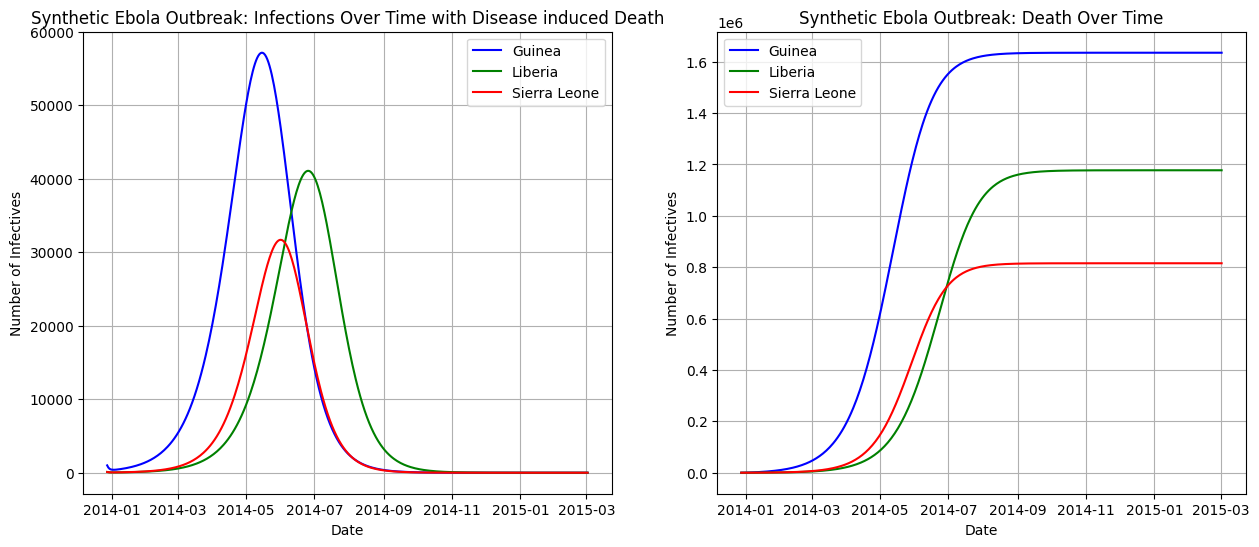

In [ ]:
# # Extract data for plotting
# days = df['Date']
# I_guinea = df['I_Guinea']
# I_liberia = df['I_Liberia']
# I_sierra_leone = df['I_SierraLeone']

# # Create the plot
# fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# ax[0].plot(days, I_guinea, label='Guinea', color='blue')
# ax[0].plot(days, I_liberia, label='Liberia', color='green')
# ax[0].plot(days, I_sierra_leone, label='Sierra Leone', color='red')
# ax[0].set_xlabel('Date')
# ax[0].set_ylabel('Number of Infectives')
# ax[0].set_title('Synthetic Ebola Outbreak: Infections Over Time with Disease induced Death')
# ax[0].legend()
# ax[0].grid(True)

# ax[1].plot(days, df['D_Guinea'], label='Guinea', color='blue')
# ax[1].plot(days, df['D_Liberia'], label='Liberia', color='green')
# ax[1].plot(days, df['D_SierraLeone'], label='Sierra Leone', color='red')
# ax[1].set_xlabel('Date')
# ax[1].set_ylabel('Number of Infectives')
# ax[1].set_title('Synthetic Ebola Outbreak: Death Over Time')
# ax[1].legend()
# ax[1].grid(True)

# # Save and show the plot
# # plt.savefig('ebola_infections_disease_death_plot.png')
# plt.show()

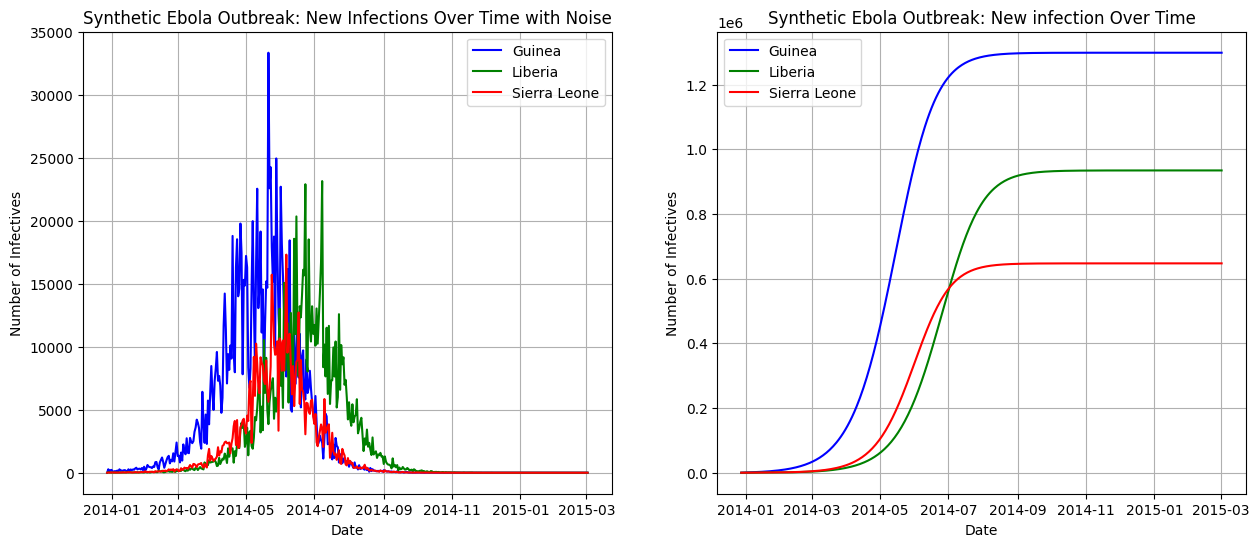

In [ ]:
# # Extract data for plotting
# days = df['Date']
# I_guinea = df['Noise_Guinea']
# I_liberia = df['Noise_Liberia']
# I_sierra_leone = df['Noise_SierraLeone']

# # Create the plot
# fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# ax[0].plot(days, I_guinea, label='Guinea', color='blue')
# ax[0].plot(days, I_liberia, label='Liberia', color='green')
# ax[0].plot(days, I_sierra_leone, label='Sierra Leone', color='red')
# ax[0].set_xlabel('Date')
# ax[0].set_ylabel('Number of Infectives')
# ax[0].set_title('Synthetic Ebola Outbreak: New Infections Over Time with Noise')
# ax[0].legend()
# ax[0].grid(True)

# ax[1].plot(days, df['C_Guinea'], label='Guinea', color='blue')
# ax[1].plot(days, df['C_Liberia'], label='Liberia', color='green')
# ax[1].plot(days, df['C_SierraLeone'], label='Sierra Leone', color='red')
# ax[1].set_xlabel('Date')
# ax[1].set_ylabel('Number of Infectives')
# ax[1].set_title('Synthetic Ebola Outbreak: New infection Over Time')
# ax[1].legend()
# ax[1].grid(True)

# # Save and show the plot
# # plt.savefig('ebola_infections_disease_death_plot.png')
# plt.show()

### 6 . Define a function to plot the SEIRD Compartments

In [ ]:
# # Plot for each country
# countries = ['Guinea', 'Liberia', 'SierraLeone']
# def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
#     # Extract data for the current country
#     S = df[f'S_{country_name}']
#     E = df[f'E_{country_name}']
#     I = df[f'I_{country_name}']
#     R = df[f'R_{country_name}']

#     # Create plot
#     plt.figure(figsize=(13, 6))
#     plt.plot(df['Date'], S, label='Susceptible', color='blue')
#     plt.plot(df['Date'], E, label='Exposed', color='orange')
#     plt.plot(df['Date'], I, label='Infective', color='red')
#     plt.plot(df['Date'], R, label='Recovered', color='green')
#     if Death:
#         D = df[f'D_{country_name}']
#         plt.plot(df['Date'], D, label='Death', color='black')

#     # Customize the plot
#     plt.xlabel('Date')
#     plt.ylabel('Number of Individuals')
#     plt.title(f'SEIRD Dynamics for {country_name}')
#     plt.legend()
#     plt.grid(True)
#     if yscale:
#         plt.yscale('symlog')  # Use symlog scale to handle large ranges
#     if save:
#         plt.savefig(f'seird_{country_name.lower()}.png')
#     plt.show()

In [19]:
# plot_SEIR(df, 'Guinea', Death=True)

In [20]:
# plot_SEIR(df, 'Liberia', Death=True)

In [21]:
# plot_SEIR(df, 'SierraLeone', Death=True)

In [ ]:
# N_countries = 3
# t = np.arange(1, T + 1)
# t0 = 0
# N = np.array([2e6, 1.5e6, 1e6]).astype(int)
# I0 = np.array([1000.0, 100.0, 100.0])

# cases = Noise.T

# # Initial conditions: [S, E, I, R, D, CumInc]
# y0 = np.zeros((N_countries, 6))
# for c in range(N_countries):
#     S0 = N[c] * 0.999 - I0[c]
#     E0 = N[c] * 0.001
#     y0[c, :] = [S0, E0, I0[c], 0.0, 0.0, 0.0]

# # Initial conditions for coupling terms: [S_ij, E_ij, I_ij, R_ij, D_ij]
# y0_ij = np.zeros((N_countries, N_countries, 5))  # Assume no initial movement

# # 2. Prepare data dictionary
# stan_data = {
#     'N_countries': N_countries,
#     'n_days': T,
#     'y0': y0,
#     'y0_ij': y0_ij,
#     't0': t0,
#     't': t,
#     'N': N,
#     'cases': cases
# }

# stan_model = CmdStanModel(stan_file='stan files/patch_with_coupling.stan')

In [16]:
# # Compile and run the Stan model
# # model = CmdStanModel(stan_file='multi_patch.stan')
# fit = stan_model.sample(data=stan_data,
#                    chains=4,
#                    iter_warmup=100,
#                    iter_sampling=100)

$$incidence_i = \sigma × (E_{ii} + \sum_{j\neq i} E_{ji})$$

In [ ]:
# print(fit.diagnose())

Checking sampler transitions treedepth.
400 of 100 (400.00%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.02, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  predicted_cases[2,1], predicted_cases[3,1], predicted_cases[4,1], predicted_cases[5,1], predicted_cases[6,1], predicted_cases[7,1], predicted_cases[8,1], predicted_cases[9,1], predicted_cases[10,1], predicted_cases[11,1], predicted_cases[12,1], p

In [ ]:
# fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-3.777510e+10,NaN,4.151230e+10,3.681930e+10,-1.004140e+11,-2.517510e+10,-3.362960e+08,NaN,NaN,NaN
beta[1],1.836890e+00,NaN,1.184340e+00,1.408140e+00,4.541670e-01,1.695070e+00,3.503270e+00,NaN,NaN,NaN
beta[2],6.275700e-01,NaN,3.199810e-01,3.506340e-01,1.772810e-01,6.925300e-01,9.479380e-01,NaN,NaN,NaN
beta[3],1.345950e+00,NaN,1.446600e+00,5.784830e-01,1.507670e-01,7.154360e-01,3.802170e+00,NaN,NaN,NaN
phi_inv,3.854550e+00,NaN,2.096970e+00,7.952150e-01,2.931060e-01,4.822640e+00,5.479840e+00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
"predicted_cases[999,2]",2.000000e-02,NaN,1.862440e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN
"predicted_cases[999,3]",2.500000e-03,NaN,5.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN
"predicted_cases[1000,1]",6.182500e+00,NaN,2.842250e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.805000e+01,NaN,NaN,NaN
"predicted_cases[1000,2]",1.150000e-01,NaN,6.463900e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-02,NaN,NaN,NaN


# 2 . Without Disease induced Deaths

### simple model without Death compartment

---
### Residents of patch i currently in patch i

---

$$
\begin{aligned}
{S'}_{ii} &= -\sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} + \sum_{k=1}^n r_{ij} S_{ii} - g_i S_{ii} \\
{E'}_{ii} &= \sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} - \sigma E_{ii} + \sum_{k=1}^n r_{ij} E_{ii} - g_i E_{ii} \\
{I'}_{ii} &= \sigma E_{ii} - \gamma I_{ii} + \sum_{k=1}^n r_{ij} I_{ii} - g_i I_{ii} \\
{R'}_{ii} &= \gamma I_{ii} + \sum_{k=1}^n r_{ij} R_{ii} - g_i R_{ii}
\end{aligned}
$$

---
### Residents of patch i currently in patch j

---
$$
\begin{aligned}
S'_{ij} &= -\sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} + g_i m_{ji}S_{ii} - r_{ij}S_{ij}\\
E'_{ij} &= \sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} - \sigma E_{ij} + g_i m_{ji}E_{ii} - r_{ij}E_{ij}\\
I'_{ij} &= \sigma E_{ij} - \gamma I_{ij} + g_im_{ji}I_{ii} - r_{ij}I_{ij}\\
R'_{ij} &= \gamma I_{ij} + g_im_{ji}R_{ii} - r_{ij}R_{ij}
\end{aligned}
$$


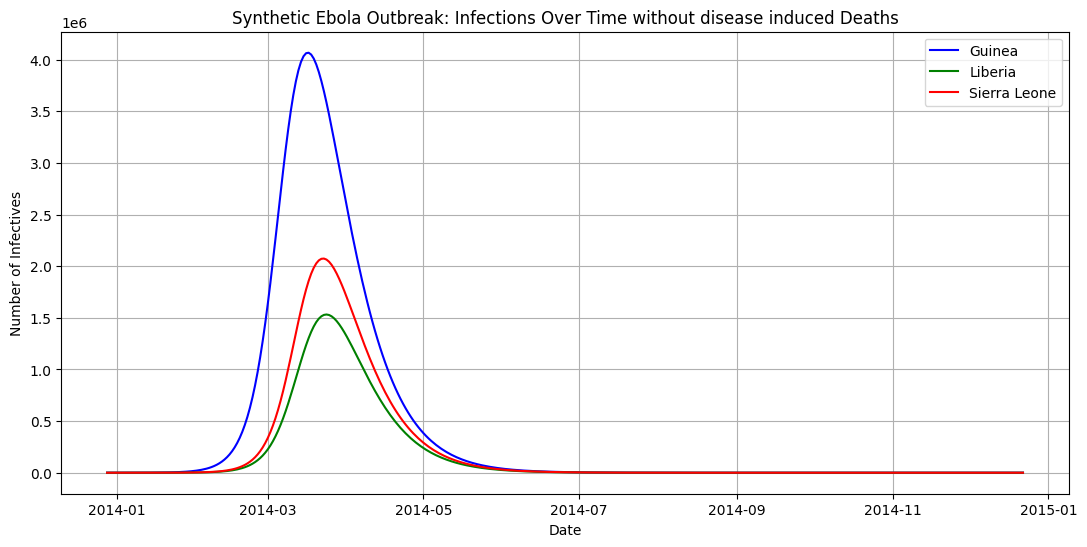

In [ ]:
# n = 3
#  ## Population per patch (Guinea, Liberia, Sierra Leone)
# N = np.array([12e6, 4.5e6, 6e6])

# ### 8·5 days (7·7–9·2) for the incubation period, 
# ### 9·3 days (8·5–10·1) for the symptom-onset-to-death delay,
# ### 13·0 days (10·4–15·7) for symptom-onset-to-recovery

# sigma = 1/8.5  # Latent period (~7 days)
# gamma = 1/13  # Recovery rate (~10 days)
# kappa = np.array([2.0, 1.5, 1.8])  # Contact rates
# beta = np.array([0.3, 0.4, 0.35]) #[0.06, 0.07, 0.08])  # Transmission probabilities

# ## Travel and return rate
# g = np.array([0.001, 0.001, 0.001])  # Travel rates
# m = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Travel fractions
# r = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Return rates

# # Initial conditions: Small outbreak in Guinea
# S01 = np.zeros((n, n))
# E01 = np.zeros((n, n))
# I01 = np.zeros((n, n))
# R01 = np.zeros((n, n))

# ## get the number of individuals currently in the patches and those traveled
# for i in range(n):
#     S01[i, i] = N[i] * 0.99
#     S01[i, (i+1)%n] = N[i] * 0.005
#     S01[i, (i+2)%n] = N[i] * 0.005

# # Initial infectives in Guinea
# I01[0, 0] = 100
# S01[0, 0] -= 100

# # Initial infectives in Liberia
# I01[1,1] = 10
# S01[1,1] -= 10

# # Initial infectives in Sierra Leone
# I01[2,2] = 10
# S01[2,2] -= 10

# y01 = np.concatenate([S01.flatten(), E01.flatten(), I01.flatten(), R01.flatten()])

# # Model equations
# def model1(y, t, n, N, sigma, gamma, kappa, beta, g, m, r):
#     S = y[:n*n].reshape(n, n)
#     E = y[n*n:2*n*n].reshape(n, n)
#     I = y[2*n*n:3*n*n].reshape(n, n)
#     R = y[3*n*n:].reshape(n, n)

#     Np = np.sum(S + E + I + R, axis=0)  # Population in each patch
#     dSdt = np.zeros((n, n))
#     dEdt = np.zeros((n, n))
#     dIdt = np.zeros((n, n))
#     dRdt = np.zeros((n, n))

#     for i in range(n):
#         ## Calculate ds_dt for the Residents of Patch i currently in Patch i
#         j = i

#         ## create the force infection
#         foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

#         ## calculate the change in the compartments
#         dSdt[i, i] = - foi + sum(r[i, k] * S[i, k] for k in range(n)) - g[i] * S[i, i]
#         dEdt[i, i] = foi - sigma * E[i, i] + sum(r[i, k] * E[i, k] for k in range(n)) - g[i] * E[i, i]
#         dIdt[i, i] = sigma * E[i, i] - gamma * I[i, i] + sum(r[i, k] * I[i, k] for k in range(n)) - g[i] * I[i, i]
#         dRdt[i, i] = gamma * I[i, i] + sum(r[i, k] * R[i, k] for k in range(n)) - g[i] * R[i, i]

#         ## Calculate ds_dt for the Residents of Patch i currently in Patch j
#         # for j in range(n):
#         #     if j != i:
#         #         ## create force of infection
#         #         foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

#         #         ## calculate the change in the compartments
#         #         dSdt[i, j] =  - foi + g[i] * m[j, i] * S[i, i] - r[i, j] * S[i, j]
#         #         dEdt[i, j] = foi - sigma * E[i, j] + g[i] * m[j, i] * E[i, i] - r[i, j] * E[i, j]
#         #         dIdt[i, j] = sigma * E[i, j] - gamma * I[i, j] + g[i] * m[j, i] * I[i, i] - r[i, j] * I[i, j]
#         #         dRdt[i, j] = gamma * I[i, j] + g[i] * m[j, i] * R[i, i] - r[i, j] * R[i, j]

#     return np.concatenate([dSdt.flatten(), dEdt.flatten(), dIdt.flatten(), dRdt.flatten()])


# T=360
# ## Solve ODE
# t = np.linspace(0, T, T)
# sol1 = odeint(model1, y01, t, args=(n, N, sigma, gamma, kappa, beta, g, m, r))

# ## Extract and aggregate results
# S1 = sol1[:, :n*n].reshape(-1, n, n)
# E1 = sol1[:, n*n:2*n*n].reshape(-1, n, n)
# I1 = sol1[:, 2*n*n:3*n*n].reshape(-1, n, n)
# R1 = sol1[:, 3*n*n:].reshape(-1, n, n)

# ## Total per patch (sum over resident patches i)
# S_total1 = np.sum(S1, axis=1)
# E_total1 = np.sum(E1, axis=1)
# I_total1 = np.sum(I1, axis=1)
# R_total1 = np.sum(R1, axis=1)

# ## Create dataset with time, totals per patch, and parameters
# data1= {
#     'Date': pd.date_range(start='2013-12-28', periods=T, freq='D'),
#     'Day': t.astype(int),
#     'S_Guinea': S_total1[:, 0],
#     'E_Guinea': E_total1[:, 0],
#     'I_Guinea': I_total1[:, 0],
#     'R_Guinea': R_total1[:, 0],

#     'S_Liberia': S_total1[:, 1],
#     'E_Liberia': E_total1[:, 1],
#     'I_Liberia': I_total1[:, 1],
#     'R_Liberia': R_total1[:, 1],

#     'S_SierraLeone': S_total1[:, 2],
#     'E_SierraLeone': E_total1[:, 2],
#     'I_SierraLeone': I_total1[:, 2],
#     'R_SierraLeone': R_total1[:, 2],
    
#     'Travel_Rate_Guinea': np.full(T, g[0]),
#     'Travel_Rate_Liberia': np.full(T, g[1]),
#     'Travel_Rate_SierraLeone': np.full(T, g[2]),
#     'Contact_Rate_Guinea': np.full(T, kappa[0]),
#     'Contact_Rate_Liberia': np.full(T, kappa[1]),
#     'Contact_Rate_SierraLeone': np.full(T, kappa[2])
# }

# ## Convert to a dataframe
# df1 = pd.DataFrame(data1)
# df.to_csv('synthetic_nodeath.csv', index=False)
# # print("Synthetic dataset saved as 'synthetic_ebola_dataset.csv'")

# ## Extract data for plotting
# days = df1['Date']
# I_guinea1 = df1['I_Guinea']
# I_liberia1 = df1['I_Liberia']
# I_sierra_leone1 = df1['I_SierraLeone']

# ## Create the plot
# plt.figure(figsize=(13, 6))
# plt.plot(days, I_guinea1, label='Guinea', color='blue')
# plt.plot(days, I_liberia1, label='Liberia', color='green')
# plt.plot(days, I_sierra_leone1, label='Sierra Leone', color='red')

# ## Customize the plot
# plt.xlabel('Date')
# plt.ylabel('Number of Infectives')
# plt.title('Synthetic Ebola Outbreak: Infections Over Time without disease induced Deaths')
# plt.legend()
# plt.grid(True)

# ## Save and show the plot
# # plt.savefig('ebola_infections_plot.png')
# plt.show()

In [ ]:
# df1

,Date,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,S_Liberia,E_Liberia,I_Liberia,R_Liberia,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,Travel_Rate_Guinea,Travel_Rate_Liberia,Travel_Rate_SierraLeone,Contact_Rate_Guinea,Contact_Rate_Liberia,Contact_Rate_SierraLeone
0,2013-12-28,0,1.193240e+07,0.000000,100.000000,0.000000e+00,4.544990e+06,0.000000,10.000000,0.000000e+00,6.022490e+06,0.000000,10.000000,0.000000e+00,0.001,0.001,0.001,2.0,1.5,1.8
1,2013-12-29,1,1.195368e+07,55.162572,95.766913,7.503916e+00,4.530760e+06,5.546914,9.618014,7.536030e-01,6.015372e+06,5.841703,9.635611,7.540678e-01,0.001,0.001,0.001,2.0,1.5,1.8
2,2013-12-30,2,1.196653e+07,103.584756,97.703869,1.492517e+01,4.522147e+06,10.456218,9.840961,1.502936e+00,6.011062e+06,11.044984,9.909940,1.506631e+00,0.001,0.001,0.001,2.0,1.5,1.8
3,2013-12-31,3,1.197428e+07,149.231014,104.813063,2.269957e+01,4.516933e+06,15.106334,10.580667,2.289965e+00,6.008452e+06,16.012353,10.733253,2.302270e+00,0.001,0.001,0.001,2.0,1.5,1.8
4,2014-01-01,4,1.197894e+07,195.184639,116.573478,3.120400e+01,4.513775e+06,19.801370,11.790602,3.152203e+00,6.006869e+06,21.075088,12.060065,3.181008e+00,0.001,0.001,0.001,2.0,1.5,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2014-12-18,355,4.925087e+03,0.000056,0.009353,1.198160e+07,1.853212e+03,0.000036,0.006113,4.507129e+06,1.673820e+03,0.000030,0.007007,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8
356,2014-12-19,356,4.925087e+03,0.000052,0.008664,1.198160e+07,1.853212e+03,0.000034,0.005663,4.507129e+06,1.673820e+03,0.000028,0.006490,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8
357,2014-12-20,357,4.925087e+03,0.000048,0.008027,1.198160e+07,1.853212e+03,0.000031,0.005246,4.507129e+06,1.673820e+03,0.000026,0.006011,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8
358,2014-12-21,358,4.925087e+03,0.000044,0.007436,1.198160e+07,1.853212e+03,0.000029,0.004860,4.507129e+06,1.673820e+03,0.000024,0.005568,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8


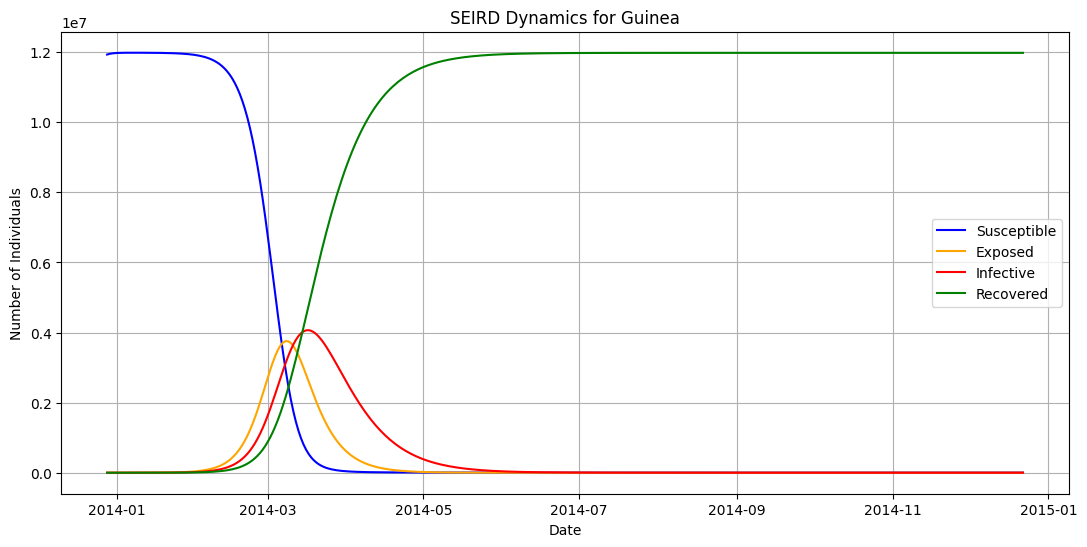

In [ ]:
# plot_SEIR(df1, 'Guinea', yscale=False)

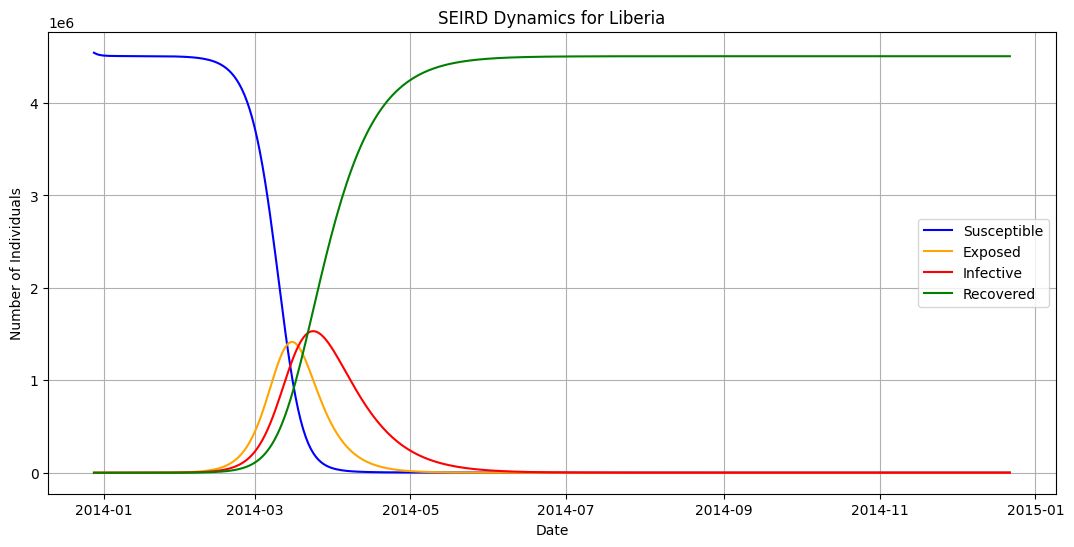

In [ ]:
# plot_SEIR(df1, 'Liberia', yscale=False)

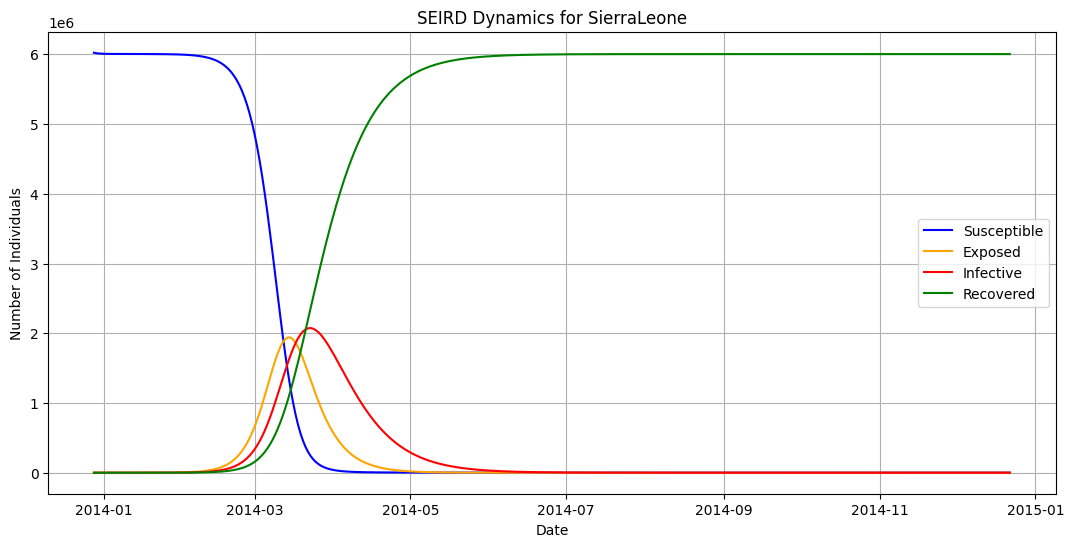

In [ ]:
# plot_SEIR(df1, 'SierraLeone', yscale=False)

In [ ]:
# # Load the synthetic dataset
# df = pd.read_csv('synthetic_ebola_dataset_with_death.csv')

# # Prepare data for Stan
# P = 3
# T = len(df)
# t0 = -1
# ts = df['Day'].values
# I_obs = df[['I_Guinea', 'I_Liberia', 'I_SierraLeone']].values.astype(int)
# D_obs = df[['D_Guinea', 'D_Liberia', 'D_SierraLeone']].values.astype(int)
# N = np.array([12e6, 4.5e6, 6e6])
# E0 = np.array([0, 0, 0])
# I0 = np.array([100, 0, 0])

# stan_data = {
#     'P': P,
#     'T': T,
#     't0': t0,
#     'ts': ts,
#     'I_obs': I_obs,
#     'D_obs': D_obs,
#     'N': N,
#     'E0': E0,
#     'I0': I0
# }

In [17]:
# # Compile and run the Stan model
# model = CmdStanModel(stan_file='coupling.stan')
# fit = model.sample(data=stan_data,
#                    chains=4,
#                    parallel_chains=4,
#                    iter_warmup=10,
#                    iter_sampling=10)

In [ ]:
# # Summarize results
# print(fit.summary())
# fit.save_csvfiles('stan_output_seird')
# print("Stan output saved in 'stan_output_seird' directory")